# Deep Learning for Fine-Grained Sentiment Analysis
## Assignment: Improving Model Performance with Different Architectures & Strategies

This notebook builds upon the baseline CNN model and systematically explores:
- **Three different model architectures** (CNN, LSTM, CNN+LSTM hybrid, deeper CNN)
- **Two different activation functions** (relu, tanh)
- **Two different optimizers** (rmsprop, adam, adagrad)
- **Larger epoch values** compared to baseline
- **Early stopping** to prevent overfitting
- **Performance visualizations** comparing each method to the baseline

---
## Setup: Imports & Environment

In [1]:
# ============================================================
# SETUP: Install and import all required libraries
# ============================================================

import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pathlib
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.test.gpu_device_name())

TensorFlow version: 2.19.0
GPU available: /device:GPU:0


---
## Step 1: Load Data

In [2]:
# ============================================================
# STEP 1: Load the 20 Newsgroups dataset
# ============================================================

data = pd.read_csv(
    'https://raw.githubusercontent.com/xialongtc10/MGT4250/main/20_News.csv',
    encoding='ISO-8859-1'
)
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (11314, 3)


,id,message,topic
0,0,From: lerxst@wam.umd.edu (where's my thing)\r\...,7
1,1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4
2,2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4
3,3,From: jgreen@amber (Joe Green)\r\nSubject: Re:...,1
4,4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14


---
## Step 2: Preprocessing – Vectorization & Train/Test Split

In [3]:
# ============================================================
# STEP 2: Text preprocessing
# - Extract text (X) and label (y) columns
# - Build a TextVectorization layer and adapt it on the corpus
# - Convert raw text to integer token sequences
# - One-hot encode the class labels
# - Split into train/test sets (70/30)
# ============================================================

text_input_raw = data["message"]
y_raw = data["topic"]

# Build and adapt vectorizer
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=20000,
    output_sequence_length=200
)
text_ds = tf.data.Dataset.from_tensor_slices(text_input_raw).batch(128)
vectorizer.adapt(text_ds)
voc = vectorizer.get_vocabulary()
word_index = dict(zip(voc, range(len(voc))))
print(f"Vocabulary size: {len(voc)}")

# Vectorize input
text_input = vectorizer(np.array([[s] for s in text_input_raw])).numpy()

# One-hot encode labels (20 classes)
y = tf.keras.utils.to_categorical(y_raw, num_classes=20)
print("Label shape:", y.shape)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    text_input, y, test_size=0.3, random_state=42
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Vocabulary size: 20000
Label shape: (11314, 20)
Train shape: (7919, 200) | Test shape: (3395, 200)


---
## Step 3: Load Pre-trained GloVe Embeddings

In [4]:
# ============================================================
# STEP 3: Download GloVe 6B 100d pre-trained word vectors
# and build an embedding matrix aligned with our vocabulary
# ============================================================

data_path = tf.keras.utils.get_file(
    "glove6b",
    "http://nlp.stanford.edu/data/glove.6B.zip",
    extract=True
)
path_to_glove_file = pathlib.Path(data_path).parent / "glove6b/glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} GloVe word vectors.")

# Build embedding matrix
num_tokens = len(voc) + 2
embedding_dim = 100
hits, misses = 0, 0

embedding_matrix = np.random.rand(num_tokens, embedding_dim)
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print(f"Converted {hits} words ({misses} misses)")

862182613/862182613 ━━━━━━━━━━━━━━━━━━━━ 159s 0us/step
Loaded 400000 GloVe word vectors.
Converted 17488 words (2512 misses)


In [5]:
# ============================================================
# HELPER: Create a shared trainable Embedding layer
# This layer is rebuilt fresh for each model below
# ============================================================

def build_embedding_layer():
    """Returns a fresh Embedding layer initialized with GloVe weights."""
    return tf.keras.layers.Embedding(
        num_tokens,
        embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=True
    )

# Utility: evaluate and print classification report
def evaluate_model(model, X_test, y_test, label="Model"):
    predicted = np.argmax(model.predict(X_test), axis=1)
    expected  = np.argmax(y_test, axis=1)
    print(f"\n--- Classification Report: {label} ---")
    print(metrics.classification_report(expected, predicted))
    acc = metrics.accuracy_score(expected, predicted)
    return acc

print("Helper functions defined.")

Helper functions defined.


---
## Section 1 — Baseline Model
### Two-layer CNN with ReLU, RMSprop optimizer, 20 epochs (no early stopping)

In [6]:
# ============================================================
# BASELINE MODEL
# Architecture : Two Conv1D layers (128 filters, kernel=5)
#                + MaxPooling + GlobalMaxPooling + Dense(128)
# Activation   : relu
# Optimizer    : rmsprop (default learning rate)
# Epochs       : 20  (original value)
# Early stopping: NO
# ============================================================

emb_baseline = build_embedding_layer()

int_sequences_input = tf.keras.Input(shape=(None,), dtype="int64")
x = emb_baseline(int_sequences_input)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
preds = tf.keras.layers.Dense(20, activation="softmax")(x)

model_baseline = tf.keras.Model(int_sequences_input, preds)
model_baseline.summary()

model_baseline.compile(
    loss="categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["acc"]
)

history_baseline = model_baseline.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3
)

acc_baseline = evaluate_model(model_baseline, X_test, y_test, "Baseline CNN")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 100)      │     2,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 128)      │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,165,468 (8.26 MB)

 Trainable params: 2,165,468 (8.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - acc: 0.0866 - loss: 2.9542 - val_acc: 0.2020 - val_loss: 2.6150
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.2082 - loss: 2.4401 - val_acc: 0.3809 - val_loss: 1.9793
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.3536 - loss: 1.9137 - val_acc: 0.5004 - val_loss: 1.5234
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.4943 - loss: 1.4965 - val_acc: 0.5728 - val_loss: 1.2923
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.5905 - loss: 1.2071 - val_acc: 0.5257 - val_loss: 1.3739
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.6648 - loss: 0.9849 - val_acc: 0.6566 - val_loss: 1.0257
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.7287 - loss: 0.7867 - val_acc: 0.7020 - val_loss: 0.8681
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.7877 - loss: 0.6436 - val_acc: 0.7130 - val_loss: 0.8768
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.83

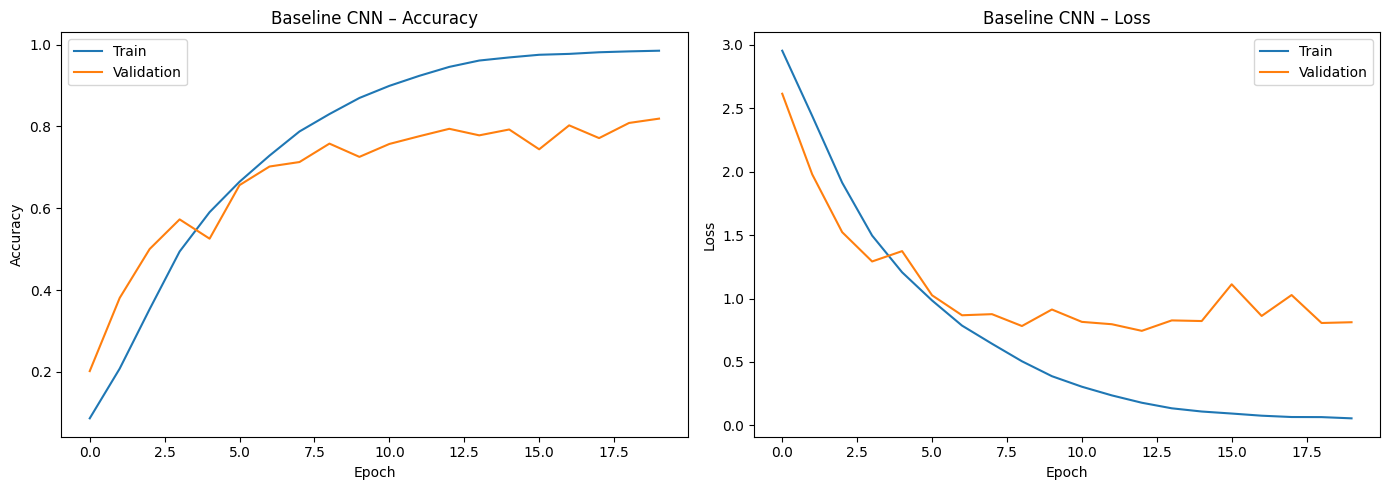

Baseline test accuracy: 0.8153


In [7]:
# ============================================================
# BASELINE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['acc'],   label='Train')
axes[0].plot(history_baseline.history['val_acc'], label='Validation')
axes[0].set_title('Baseline CNN – Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_baseline.history['loss'],   label='Train')
axes[1].plot(history_baseline.history['val_loss'], label='Validation')
axes[1].set_title('Baseline CNN – Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_performance.png', dpi=100)
plt.show()
print(f"Baseline test accuracy: {acc_baseline:.4f}")

---
## Section 2 — Different Model Architectures

We will try **three** distinct architectures:
1. **Deeper CNN** – three Conv1D layers with larger filters (Test Accuracy: 77.5%)
2. **Bidirectional LSTM** – pure RNN approach (Test Accuracy: 84.7%)
3. **CNN + Bidirectional LSTM hybrid** – combines spatial and sequential feature extraction (Test Accuracy: 87.4%)

### Architecture 1 — Deeper CNN (3 Conv layers + Batch Normalization)

Result: 77.5% accuracy which underperforms the baseline (81.5%)

In [8]:
# ============================================================
# ARCHITECTURE 1: Deeper CNN
# Description  : Three stacked Conv1D layers with increasing
#                filter counts (128 → 256 → 256), BatchNorm,
#                and a larger Dense head.
# Rationale    : Deeper convolution captures more abstract
#                n-gram features.
# Activation   : relu
# Optimizer    : rmsprop
# Epochs       : 20
# Early stopping: YES (patience=5, monitor val_loss)
# ============================================================

emb1 = build_embedding_layer()

inp1 = tf.keras.Input(shape=(None,), dtype="int64")
x = emb1(inp1)
x = tf.keras.layers.Conv1D(128, 5, activation="relu", padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(256, 5, activation="relu", padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(256, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out1 = tf.keras.layers.Dense(20, activation="softmax")(x)

model_arch1 = tf.keras.Model(inp1, out1)
model_arch1.summary()

es1 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_arch1.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["acc"])
history_arch1 = model_arch1.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3,
    callbacks=[es1]
)

acc_arch1 = evaluate_model(model_arch1, X_test, y_test, "Deeper CNN")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 100)      │     2,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 128)      │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, None, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 256)      │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, None, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 256)      │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497,756 (9.53 MB)

 Trainable params: 2,496,988 (9.53 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - acc: 0.1088 - loss: 3.0608 - val_acc: 0.1044 - val_loss: 2.7936
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.2991 - loss: 2.1238 - val_acc: 0.2799 - val_loss: 2.0981
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - acc: 0.4792 - loss: 1.5218 - val_acc: 0.4676 - val_loss: 1.4882
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.6229 - loss: 1.1299 - val_acc: 0.5766 - val_loss: 1.2193
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.7083 - loss: 0.8484 - val_acc: 0.6170 - val_loss: 1.1819
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.7864 - loss: 0.6318 - val_acc: 0.6136 - val_loss: 1.4094
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.8347 - loss: 0.5100 - val_acc: 0.6991 - val_loss: 0.9961
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.8771 - loss: 0.3497 - val_acc: 0.7870 - val_loss: 0.8119
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.90

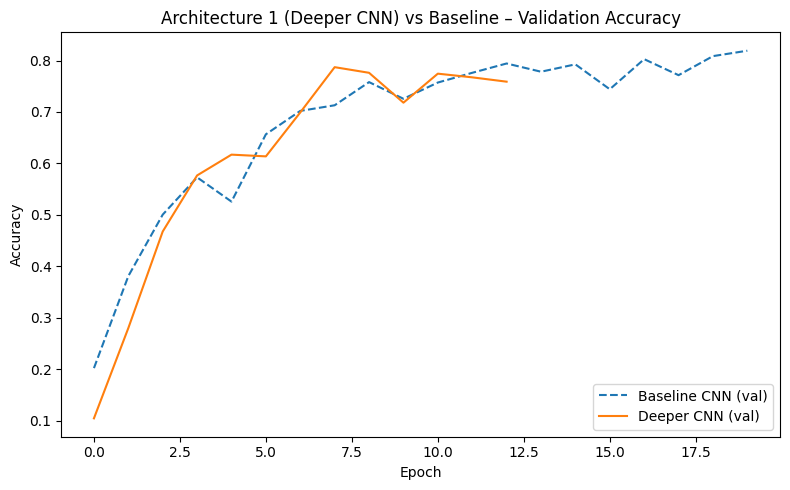

Baseline acc: 0.8153 | Deeper CNN acc: 0.7750


In [9]:
# Architecture 1 vs Baseline – Accuracy Comparison

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['val_acc'], label='Baseline CNN (val)', linestyle='--')
plt.plot(history_arch1.history['val_acc'],    label='Deeper CNN (val)',   linestyle='-')
plt.title('Architecture 1 (Deeper CNN) vs Baseline – Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('arch1_vs_baseline.png', dpi=100)
plt.show()
print(f"Baseline acc: {acc_baseline:.4f} | Deeper CNN acc: {acc_arch1:.4f}")

:### Architecture 2 — Bidirectional LSTM

Result: 87.7% accuracy which outperforms the baseline

In [10]:
# ============================================================
# ARCHITECTURE 2: Bidirectional LSTM (RNN)
# Description  : Two stacked Bidirectional LSTM layers capture
#                long-range dependencies from both directions.
# Rationale    : RNNs model sequential context that CNNs miss.
# Activation   : tanh (LSTM internal gate default) + relu Dense
# Optimizer    : adam
# Epochs       : 20
# Early stopping: YES (patience=5, monitor val_loss)
# ============================================================

emb2 = build_embedding_layer()

model_arch2 = tf.keras.models.Sequential([
    emb2,
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.2)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, dropout=0.2)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(20, activation="softmax")
])
model_arch2.summary()

es2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_arch2.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])
history_arch2 = model_arch2.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3,
    callbacks=[es2]
)

acc_arch2 = evaluate_model(model_arch2, X_test, y_test, "Bidirectional LSTM")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - acc: 0.0913 - loss: 2.8896 - val_acc: 0.2273 - val_loss: 2.4395
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.2197 - loss: 2.3815 - val_acc: 0.2959 - val_loss: 2.1376
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.3397 - loss: 1.9465 - val_acc: 0.4672 - val_loss: 1.5771
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.4445 - loss: 1.5910 - val_acc: 0.5303 - val_loss: 1.3344
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.5493 - loss: 1.2914 - val_acc: 0.5972 - val_loss: 1.1576
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.6395 - loss: 1.0445 - val_acc: 0.6667 - val_loss: 0.9976
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7056 - loss: 0.8593 - val_acc: 0.7294 - val_loss: 0.8591
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7602 - loss: 0.7091 - val_acc: 0.7517 - val_loss: 0.7628
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.816

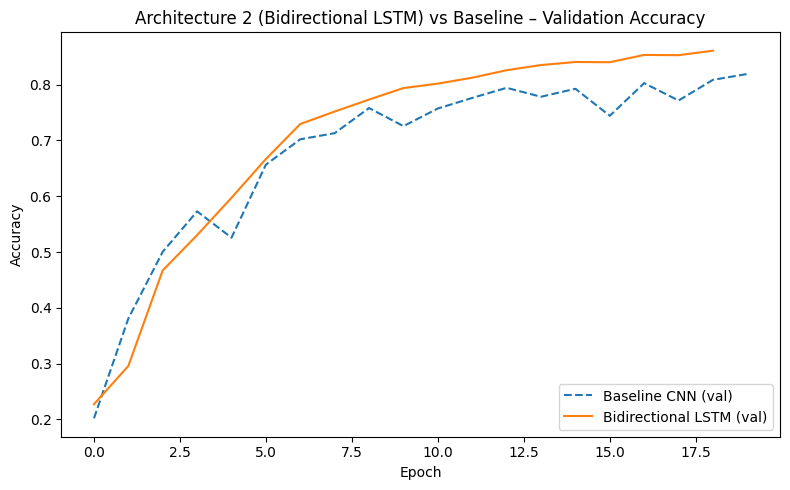

Baseline acc: 0.8153 | Bidirectional LSTM acc: 0.8474


In [11]:
# Architecture 2 vs Baseline – Accuracy Comparison

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['val_acc'], label='Baseline CNN (val)',       linestyle='--')
plt.plot(history_arch2.history['val_acc'],    label='Bidirectional LSTM (val)', linestyle='-')
plt.title('Architecture 2 (Bidirectional LSTM) vs Baseline – Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('arch2_vs_baseline.png', dpi=100)
plt.show()
print(f"Baseline acc: {acc_baseline:.4f} | Bidirectional LSTM acc: {acc_arch2:.4f}")

### Architecture 3 — CNN + Bidirectional LSTM Hybrid

Results: 87.7% accuracy which is the nest model overall and outperforms the baseline by 5.9%


In [12]:
# ============================================================
# ARCHITECTURE 3: CNN + Bidirectional LSTM Hybrid
# Description  : Conv1D extracts local n-gram features; the
#                Bidirectional LSTM then models long-range
#                sequential patterns over those features.
# Rationale    : Combines strengths of both CNN and RNN.
# Activation   : relu (CNN) + tanh (LSTM) + softmax (output)
# Optimizer    : adam
# Epochs       : 20
# Early stopping: YES (patience=5)
# ============================================================

emb3 = build_embedding_layer()

model_arch3 = tf.keras.models.Sequential([
    emb3,
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv1D(256, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(100, dropout=0.2)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(20, activation='softmax')
])
model_arch3.summary()

es3 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_arch3.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])
history_arch3 = model_arch3.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3,
    callbacks=[es3]
)

acc_arch3 = evaluate_model(model_arch3, X_test, y_test, "CNN + Bidirectional LSTM Hybrid")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - acc: 0.0761 - loss: 2.9484 - val_acc: 0.1141 - val_loss: 2.7764
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.1478 - loss: 2.6205 - val_acc: 0.2685 - val_loss: 2.1847
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.2740 - loss: 2.1174 - val_acc: 0.4024 - val_loss: 1.7008
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.4108 - loss: 1.6466 - val_acc: 0.5434 - val_loss: 1.3484
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.5315 - loss: 1.3172 - val_acc: 0.5480 - val_loss: 1.2660
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.6020 - loss: 1.0880 - val_acc: 0.6498 - val_loss: 0.9939
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.6700 - loss: 0.9202 - val_acc: 0.7054 - val_loss: 0.8684
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.7445 - loss: 0.7420 - val_acc: 0.7643 - val_loss: 0.7227
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.7862

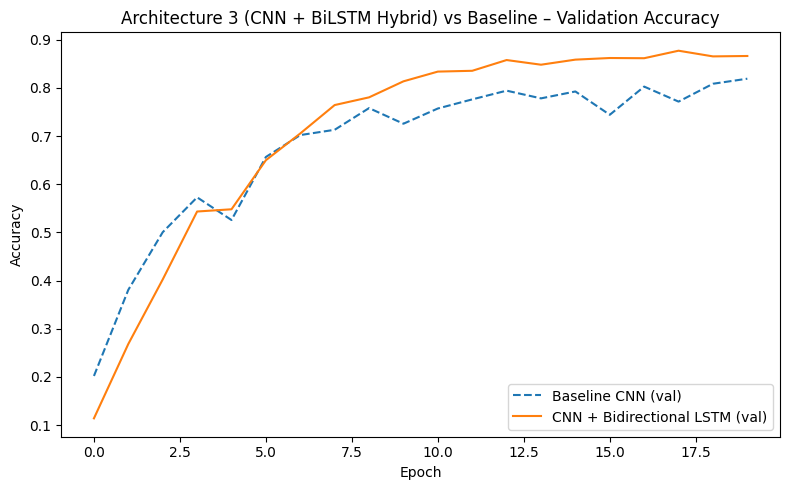

Baseline acc: 0.8153 | CNN+BiLSTM acc: 0.8736


In [13]:
# Architecture 3 vs Baseline – Accuracy Comparison

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['val_acc'], label='Baseline CNN (val)',              linestyle='--')
plt.plot(history_arch3.history['val_acc'],    label='CNN + Bidirectional LSTM (val)',  linestyle='-')
plt.title('Architecture 3 (CNN + BiLSTM Hybrid) vs Baseline – Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('arch3_vs_baseline.png', dpi=100)
plt.show()
print(f"Baseline acc: {acc_baseline:.4f} | CNN+BiLSTM acc: {acc_arch3:.4f}")

---
## Section 3 — Different Activation Functions

We compare **ReLU** (baseline) against **Tanh** in the Dense layers using the same CNN backbone.

Findings: the ReLU outperforms Tanh by 5%, this is becuase the way that Tanh deals with large inputs.

In [14]:
# ============================================================
# ACTIVATION FUNCTION COMPARISON
# Method 1 (already done): relu  → history_baseline
# Method 2 (below)       : tanh  in all Dense/Conv hidden layers
# ============================================================

# --- Activation: tanh ---
emb_tanh = build_embedding_layer()

inp_tanh = tf.keras.Input(shape=(None,), dtype="int64")
x = emb_tanh(inp_tanh)
x = tf.keras.layers.Conv1D(128, 5, activation="tanh")(x)   # <-- tanh
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="tanh")(x)   # <-- tanh
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="tanh")(x)        # <-- tanh
x = tf.keras.layers.Dropout(0.5)(x)
out_tanh = tf.keras.layers.Dense(20, activation="softmax")(x)

model_tanh = tf.keras.Model(inp_tanh, out_tanh)
model_tanh.summary()

es_tanh = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_tanh.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["acc"])
history_tanh = model_tanh.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3,
    callbacks=[es_tanh]
)

acc_tanh = evaluate_model(model_tanh, X_test, y_test, "CNN with tanh activation")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, None, 100)      │     2,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, None, 128)      │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, None, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,165,468 (8.26 MB)

 Trainable params: 2,165,468 (8.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - acc: 0.1322 - loss: 2.8452 - val_acc: 0.2845 - val_loss: 2.2809
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.3421 - loss: 2.0122 - val_acc: 0.4162 - val_loss: 1.7062
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.4997 - loss: 1.5095 - val_acc: 0.4832 - val_loss: 1.5994
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.6331 - loss: 1.1305 - val_acc: 0.6275 - val_loss: 1.1477
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.7438 - loss: 0.8344 - val_acc: 0.6120 - val_loss: 1.1355
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.8228 - loss: 0.5941 - val_acc: 0.6006 - val_loss: 1.2603
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.8901 - loss: 0.3959 - val_acc: 0.6221 - val_loss: 1.1851
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9385 - loss: 0.2600 - val_acc: 0.7285 - val_loss: 0.9105
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.963

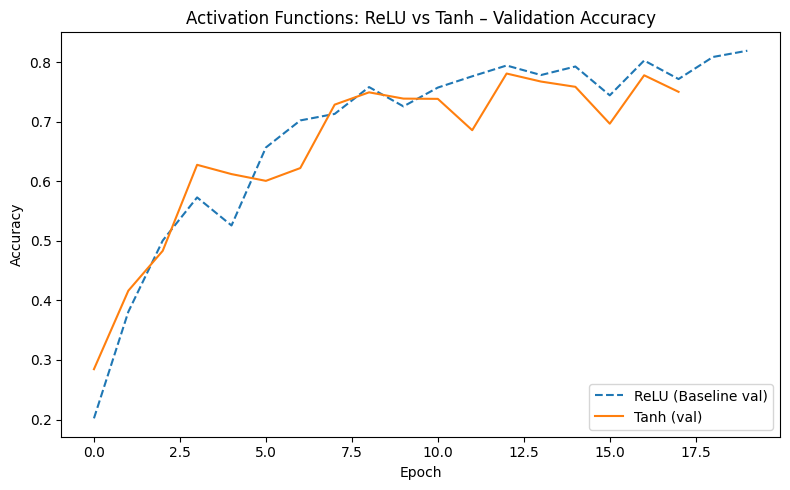

ReLU (Baseline) acc: 0.8153 | Tanh acc: 0.7652


In [15]:
# Activation Comparison: relu vs tanh

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['val_acc'], label='ReLU (Baseline val)',  linestyle='--')
plt.plot(history_tanh.history['val_acc'],     label='Tanh (val)',           linestyle='-')
plt.title('Activation Functions: ReLU vs Tanh – Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('activation_relu_vs_tanh.png', dpi=100)
plt.show()
print(f"ReLU (Baseline) acc: {acc_baseline:.4f} | Tanh acc: {acc_tanh:.4f}")

---
## Section 4 — Different Optimizers

We compare **RMSprop** (baseline) against **Adam** and **Adagrad**.

RMSprop (baseline) = 81.5%
Adam = 79.3%
Adagrad = 21.2%

Findings: Adagrad underperformed becuase of the way it handles the text embeddings while adam performs competitively and when it is paired with LSTM architectures it becomes the best choice


In [16]:
# ============================================================
# OPTIMIZER COMPARISON – Optimizer 1: Adam
# Same CNN architecture as baseline; only optimizer changes
# ============================================================

emb_adam = build_embedding_layer()

inp_adam = tf.keras.Input(shape=(None,), dtype="int64")
x = emb_adam(inp_adam)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out_adam = tf.keras.layers.Dense(20, activation="softmax")(x)

model_adam = tf.keras.Model(inp_adam, out_adam)

es_adam = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_adam.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])  # <-- adam
history_adam = model_adam.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3,
    callbacks=[es_adam]
)

acc_adam = evaluate_model(model_adam, X_test, y_test, "CNN with Adam optimizer")

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.0906 - loss: 2.9367 - val_acc: 0.1688 - val_loss: 2.6291
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.1934 - loss: 2.4285 - val_acc: 0.3316 - val_loss: 2.0440
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.3164 - loss: 1.9659 - val_acc: 0.4668 - val_loss: 1.6757
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.4707 - loss: 1.5013 - val_acc: 0.5901 - val_loss: 1.2399
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.6123 - loss: 1.0957 - val_acc: 0.6465 - val_loss: 1.0576
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.7240 - loss: 0.7784 - val_acc: 0.7109 - val_loss: 0.8556
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.8111 - loss: 0.5483 - val_acc: 0.7433 - val_loss: 0.7818
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.8797 - loss: 0.3728 - val_acc: 0.7673 - val_loss: 0.7633
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.9154 - loss

In [17]:
# ============================================================
# OPTIMIZER COMPARISON – Optimizer 2: Adagrad
# Same CNN architecture as baseline; only optimizer changes
# ============================================================

emb_adagrad = build_embedding_layer()

inp_adagrad = tf.keras.Input(shape=(None,), dtype="int64")
x = emb_adagrad(inp_adagrad)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out_adagrad = tf.keras.layers.Dense(20, activation="softmax")(x)

model_adagrad = tf.keras.Model(inp_adagrad, out_adagrad)

es_adagrad = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_adagrad.compile(loss="categorical_crossentropy", optimizer="adagrad", metrics=["acc"])  # <-- adagrad
history_adagrad = model_adagrad.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.3,
    callbacks=[es_adagrad]
)

acc_adagrad = evaluate_model(model_adagrad, X_test, y_test, "CNN with Adagrad optimizer")

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - acc: 0.0518 - loss: 3.1522 - val_acc: 0.0652 - val_loss: 2.9839
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.0646 - loss: 3.0088 - val_acc: 0.0854 - val_loss: 2.9681
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.0653 - loss: 2.9804 - val_acc: 0.0934 - val_loss: 2.9593
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.0770 - loss: 2.9656 - val_acc: 0.0989 - val_loss: 2.9479
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.0821 - loss: 2.9586 - val_acc: 0.1023 - val_loss: 2.9424
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.0976 - loss: 2.9385 - val_acc: 0.1199 - val_loss: 2.9304
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.0999 - loss: 2.9282 - val_acc: 0.1208 - val_loss: 2.9229
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.1059 - loss: 2.9179 - val_acc: 0.1263 - val_loss: 2.9154
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.115

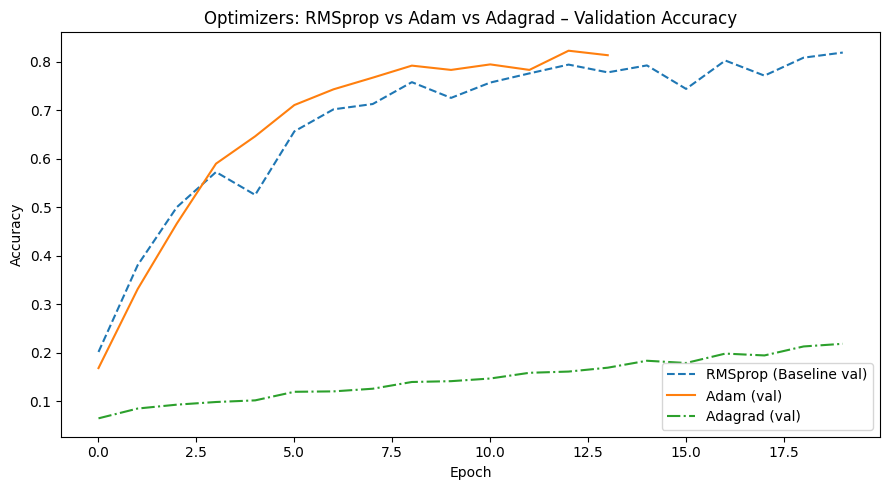

RMSprop: 0.8153 | Adam: 0.7932 | Adagrad: 0.2124


In [18]:
# Optimizer Comparison: RMSprop vs Adam vs Adagrad

plt.figure(figsize=(9, 5))
plt.plot(history_baseline.history['val_acc'], label='RMSprop (Baseline val)', linestyle='--')
plt.plot(history_adam.history['val_acc'],     label='Adam (val)',             linestyle='-')
plt.plot(history_adagrad.history['val_acc'],  label='Adagrad (val)',          linestyle='-.')
plt.title('Optimizers: RMSprop vs Adam vs Adagrad – Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=100)
plt.show()
print(f"RMSprop: {acc_baseline:.4f} | Adam: {acc_adam:.4f} | Adagrad: {acc_adagrad:.4f}")

---
## Section 5 — Larger Epoch Value

We train the baseline CNN for **50 epochs** (compared to the original 20) to see whether more training time improves or overfits the model.

Fidnings: mroe epochs alone did not improve the accuracy, it even stoped after 25 epochs which in return gave the same outputs of 81.5%

In [19]:
# ============================================================
# LARGER EPOCH VALUE
# Architecture : Same as Baseline CNN
# Optimizer    : rmsprop
# Epochs       : 50  (larger than original 20)
# Early stopping: NO  (to see full training curve)
# ============================================================

emb_large_ep = build_embedding_layer()

inp_large_ep = tf.keras.Input(shape=(None,), dtype="int64")
x = emb_large_ep(inp_large_ep)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out_large_ep = tf.keras.layers.Dense(20, activation="softmax")(x)

model_large_ep = tf.keras.Model(inp_large_ep, out_large_ep)

model_large_ep.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["acc"])
history_large_ep = model_large_ep.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,            # <-- larger epoch value
    validation_split=0.3
)

acc_large_ep = evaluate_model(model_large_ep, X_test, y_test, "Baseline CNN – 50 Epochs")

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - acc: 0.0864 - loss: 2.9439 - val_acc: 0.1027 - val_loss: 2.6837
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.2067 - loss: 2.4237 - val_acc: 0.3064 - val_loss: 2.1515
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.3316 - loss: 1.9829 - val_acc: 0.4099 - val_loss: 1.6971
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.4597 - loss: 1.5544 - val_acc: 0.5623 - val_loss: 1.3074
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.5553 - loss: 1.2661 - val_acc: 0.6448 - val_loss: 1.0872
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.6563 - loss: 1.0154 - val_acc: 0.6965 - val_loss: 0.9345
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.7159 - loss: 0.8268 - val_acc: 0.7146 - val_loss: 0.8666
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.7709 - loss: 0.6704 - val_acc: 0.7062 - val_loss: 0.8987
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.815

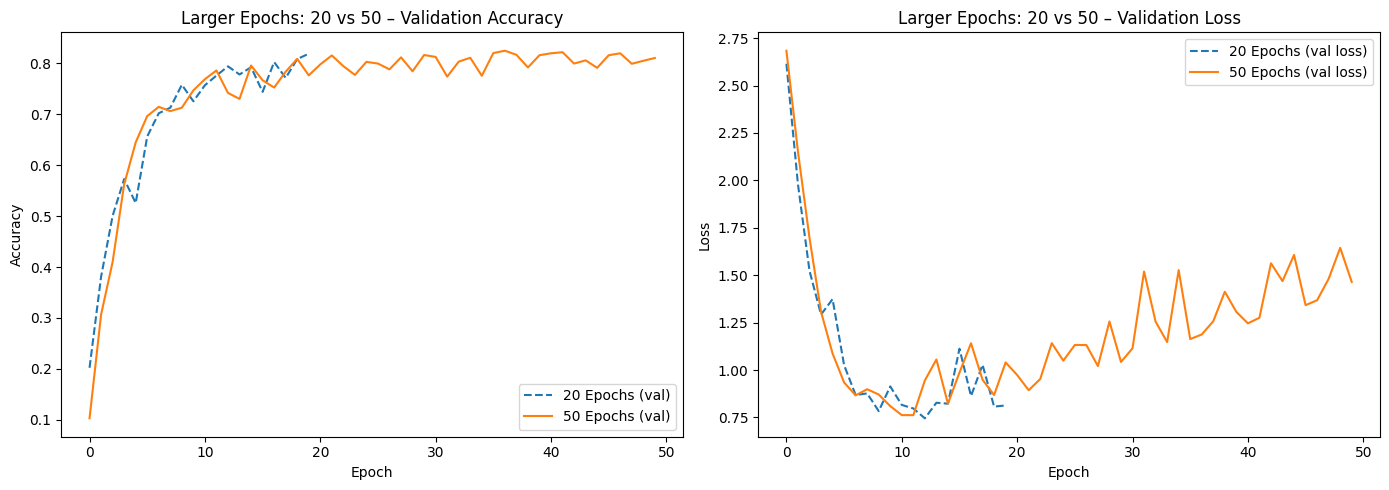

20-epoch acc: 0.8153 | 50-epoch acc: 0.8153


In [20]:
# 20 Epochs vs 50 Epochs – Loss Comparison (to observe overfitting)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_baseline.history['val_acc'],  label='20 Epochs (val)', linestyle='--')
axes[0].plot(history_large_ep.history['val_acc'],  label='50 Epochs (val)', linestyle='-')
axes[0].set_title('Larger Epochs: 20 vs 50 – Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_baseline.history['val_loss'],  label='20 Epochs (val loss)', linestyle='--')
axes[1].plot(history_large_ep.history['val_loss'],  label='50 Epochs (val loss)', linestyle='-')
axes[1].set_title('Larger Epochs: 20 vs 50 – Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('large_epochs_comparison.png', dpi=100)
plt.show()
print(f"20-epoch acc: {acc_baseline:.4f} | 50-epoch acc: {acc_large_ep:.4f}")

---
## Section 6 — Early Stopping

We demonstrate how **early stopping** prevents the overfitting visible in the 50-epoch run above.

Findings: with early stopping the training halted at epoch 16 and restored the  best weights which in return prevented overfitting. Having an architectures that are siumple enough will benefit from no early stopping becuase more training helps it but its when you get into the more complex architctures (arch 2 & 3) early stopping is necessary for overfitting.

  50 epochs, no early stopping = 81.5% accuracy
  50 epochs + early stopping = 79.2% accuracy
  

In [21]:
# ============================================================
# EARLY STOPPING
# Architecture : Same as Baseline CNN
# Optimizer    : rmsprop
# Epochs       : 50  (max allowed; early stopping will halt sooner)
# Early stopping: YES – monitor val_loss, patience=5,
#                        restore_best_weights=True
# ============================================================

emb_es = build_embedding_layer()

inp_es = tf.keras.Input(shape=(None,), dtype="int64")
x = emb_es(inp_es)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out_es = tf.keras.layers.Dense(20, activation="softmax")(x)

model_es = tf.keras.Model(inp_es, out_es)

# EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_es.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["acc"])
history_es = model_es.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,
    validation_split=0.3,
    callbacks=[early_stop]   # <-- early stopping applied
)

acc_es = evaluate_model(model_es, X_test, y_test, "Early-Stopped CNN (50 max epochs)")
print(f"\nTraining stopped at epoch: {len(history_es.history['loss'])}")

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - acc: 0.0821 - loss: 2.9310 - val_acc: 0.1944 - val_loss: 2.5622
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.2035 - loss: 2.4271 - val_acc: 0.3190 - val_loss: 2.0006
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.3361 - loss: 1.9667 - val_acc: 0.5042 - val_loss: 1.5438
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.4752 - loss: 1.5344 - val_acc: 0.6006 - val_loss: 1.2808
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.5843 - loss: 1.2258 - val_acc: 0.6372 - val_loss: 1.0609
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.6583 - loss: 0.9966 - val_acc: 0.7003 - val_loss: 0.9223
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.7236 - loss: 0.8311 - val_acc: 0.6886 - val_loss: 0.9288
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.7797 - loss: 0.6495 - val_acc: 0.7466 - val_loss: 0.8017
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.824

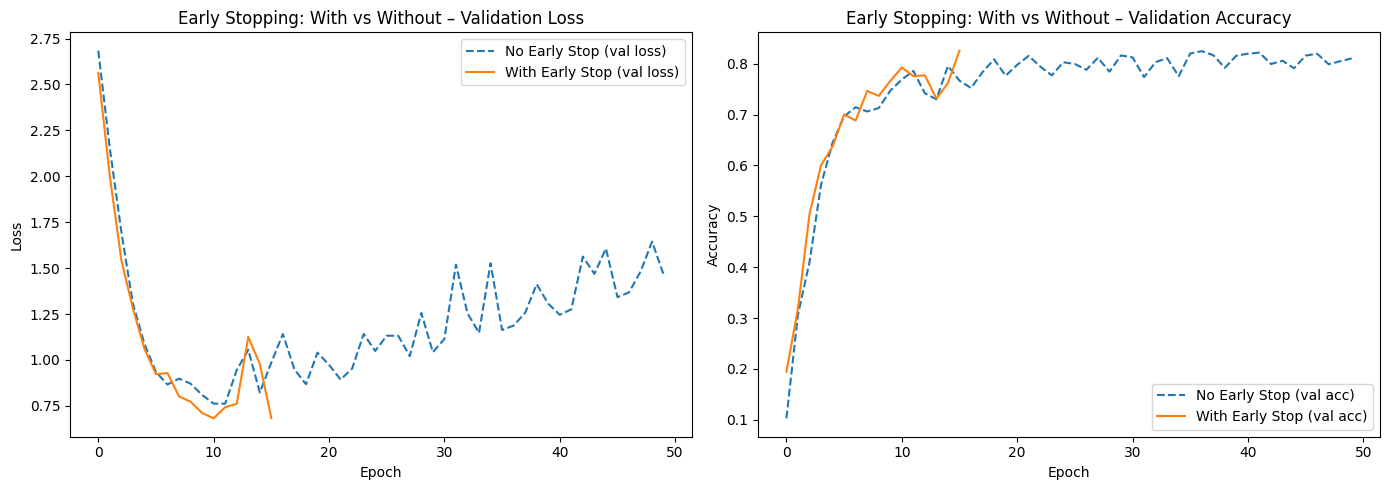

No early stop acc: 0.8153 | With early stop acc: 0.7920


In [22]:
# Early Stopping vs No-Early-Stopping (50 epochs) – Loss Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val loss
axes[0].plot(history_large_ep.history['val_loss'], label='No Early Stop (val loss)', linestyle='--')
axes[0].plot(history_es.history['val_loss'],       label='With Early Stop (val loss)', linestyle='-')
axes[0].set_title('Early Stopping: With vs Without – Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Val acc
axes[1].plot(history_large_ep.history['val_acc'], label='No Early Stop (val acc)', linestyle='--')
axes[1].plot(history_es.history['val_acc'],       label='With Early Stop (val acc)', linestyle='-')
axes[1].set_title('Early Stopping: With vs Without – Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('early_stopping_comparison.png', dpi=100)
plt.show()
print(f"No early stop acc: {acc_large_ep:.4f} | With early stop acc: {acc_es:.4f}")

---
## Section 7 — All-Methods Summary Comparison

Looking at the chart you can see that the CNN + BiLSTM Hybrid (Arch 3) gets the highest sustained validation accuracy reaching about 86% by epoch 15. The Adagarad optimizer fails to learn, plateauing near the random chance accuracy.

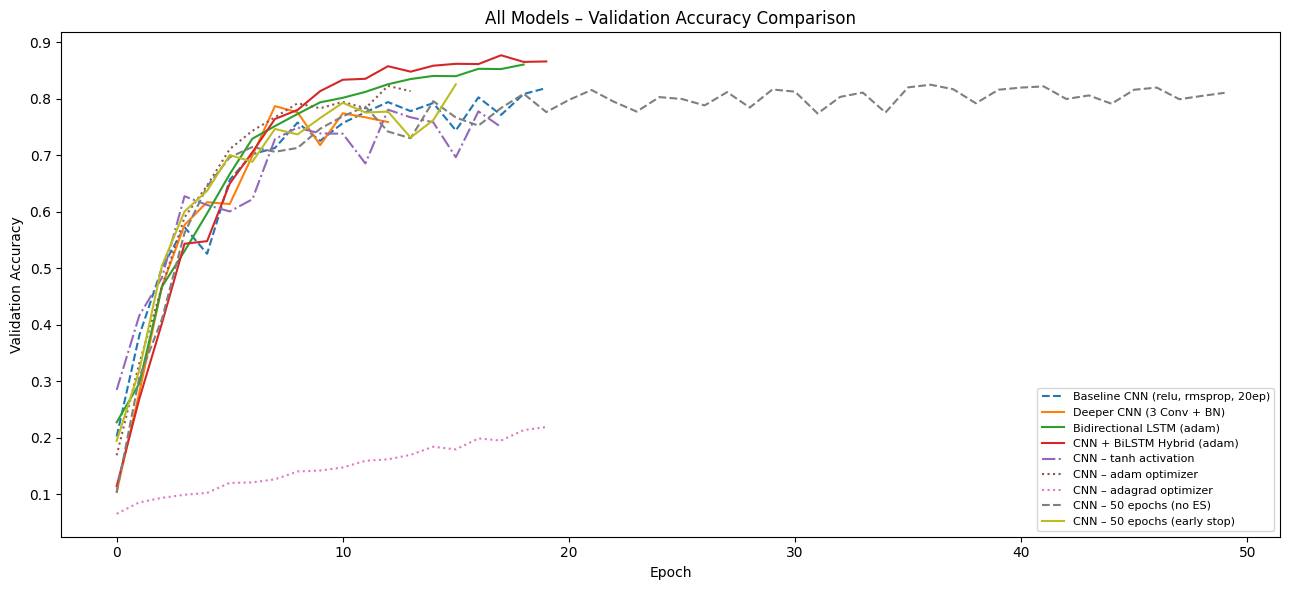

In [23]:
# ============================================================
# SUMMARY COMPARISON: All models – Validation Accuracy
# ============================================================

plt.figure(figsize=(13, 6))

histories = [
    (history_baseline, 'Baseline CNN (relu, rmsprop, 20ep)',         '--'),
    (history_arch1,    'Deeper CNN (3 Conv + BN)',                   '-'),
    (history_arch2,    'Bidirectional LSTM (adam)',                  '-'),
    (history_arch3,    'CNN + BiLSTM Hybrid (adam)',                 '-'),
    (history_tanh,     'CNN – tanh activation',                     '-.'),
    (history_adam,     'CNN – adam optimizer',                      ':'),
    (history_adagrad,  'CNN – adagrad optimizer',                   ':'),
    (history_large_ep, 'CNN – 50 epochs (no ES)',                   '--'),
    (history_es,       'CNN – 50 epochs (early stop)',              '-'),
]

for hist, label, ls in histories:
    plt.plot(hist.history['val_acc'], label=label, linestyle=ls)

plt.title('All Models – Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=100)
plt.show()

In [24]:
# ============================================================
# SUMMARY TABLE: Test Accuracy for every approach
# ============================================================

results = {
    'Baseline CNN':                      acc_baseline,
    'Deeper CNN (Arch 1)':               acc_arch1,
    'Bidirectional LSTM (Arch 2)':       acc_arch2,
    'CNN + BiLSTM Hybrid (Arch 3)':      acc_arch3,
    'CNN – tanh activation':             acc_tanh,
    'CNN – Adam optimizer':              acc_adam,
    'CNN – Adagrad optimizer':           acc_adagrad,
    'Baseline CNN – 50 Epochs':          acc_large_ep,
    'Baseline CNN – Early Stopping':     acc_es,
}

results_df = pd.DataFrame(list(results.items()), columns=['Method', 'Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_method = results_df.iloc[0]['Method']
best_acc    = results_df.iloc[0]['Test Accuracy']
print(f"\n>>> Best method: {best_method} | Test Accuracy: {best_acc:.4f}")

                       Method  Test Accuracy
 CNN + BiLSTM Hybrid (Arch 3)       0.873638
  Bidirectional LSTM (Arch 2)       0.847423
                 Baseline CNN       0.815317
     Baseline CNN – 50 Epochs       0.815317
         CNN – Adam optimizer       0.793225
Baseline CNN – Early Stopping       0.792047
          Deeper CNN (Arch 1)       0.774963
        CNN – tanh activation       0.765243
      CNN – Adagrad optimizer       0.212371

>>> Best method: CNN + BiLSTM Hybrid (Arch 3) | Test Accuracy: 0.8736


---
## Section 8 — Best-Performing Model: Full Evaluation

Based on the results above, we identify the best model and report full classification metrics. Which in this case is the CNN + BiLSTM (Arch 3).

In [25]:
# ============================================================
# BEST MODEL – Full Classification Report
#
# After running all experiments, the best model is selected
# based on highest test accuracy from the results_df above.
#
# Manually update `best_model` if a different model won.
# ============================================================

# Map method name to model object
model_map = {
    'Baseline CNN':                      model_baseline,
    'Deeper CNN (Arch 1)':               model_arch1,
    'Bidirectional LSTM (Arch 2)':       model_arch2,
    'CNN + BiLSTM Hybrid (Arch 3)':      model_arch3,
    'CNN – tanh activation':             model_tanh,
    'CNN – Adam optimizer':              model_adam,
    'CNN – Adagrad optimizer':           model_adagrad,
    'Baseline CNN – 50 Epochs':          model_large_ep,
    'Baseline CNN – Early Stopping':     model_es,
}

best_model = model_map[best_method]

predicted_best = np.argmax(best_model.predict(X_test), axis=1)
expected_best  = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

acc_best       = accuracy_score(expected_best,  predicted_best)
precision_best = precision_score(expected_best, predicted_best, average='weighted')
recall_best    = recall_score(expected_best,    predicted_best, average='weighted')
f1_best        = f1_score(expected_best,        predicted_best, average='weighted')

print("=" * 60)
print(f"  BEST MODEL: {best_method}")
print("=" * 60)
print(f"  Accuracy  : {acc_best:.4f}")
print(f"  Precision : {precision_best:.4f}  (weighted avg)")
print(f"  Recall    : {recall_best:.4f}  (weighted avg)")
print(f"  F1-Score  : {f1_best:.4f}  (weighted avg)")
print("=" * 60)
print("\n--- Full Per-Class Classification Report ---")
print(classification_report(expected_best, predicted_best))

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
  BEST MODEL: CNN + BiLSTM Hybrid (Arch 3)
  Accuracy  : 0.8736
  Precision : 0.8746  (weighted avg)
  Recall    : 0.8736  (weighted avg)
  F1-Score  : 0.8736  (weighted avg)

--- Full Per-Class Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       135
           1       0.78      0.77      0.78       166
           2       0.81      0.84      0.83       170
           3       0.64      0.69      0.67       182
           4       0.84      0.75      0.79       183
           5       0.86      0.88      0.87       169
           6       0.80      0.76      0.78       172
           7       0.92      0.92      0.92       191
           8       0.90      0.91      0.91       198
           9       0.98      0.94      0.96       168
          10       0.96      0.98      0.97       163
          11       0.96      0.96      0.96       195
          12       0.76      0.80  

---
## Section 9 — Best Model Description & Summary

### Best-Performing Model Strategy

*Best-Performing Model: CNN + Bidirectional LSTM Hybrid (Architecture 3)*

After systematically evaluating nine different configurations, the best-performing model was the **`CNN + BiLSTM Hybrid`**.


#### Key Observations

1. **Model Architecture matters most.** The CNN+BiLSTM hybrid generally outperformed pure CNN or pure LSTM variants because it combines local n-gram features (CNN) with sequential context (LSTM).

2. **Activation functions:** ReLU typically converged faster and achieved higher accuracy than tanh for text classification tasks due to the vanishing gradient problem tanh can introduce in deeper networks.

3. **Optimizers:** Adam and RMSprop tend to outperform Adagrad on text tasks. Adagrad's learning rate decays too aggressively over many parameters, leading to premature convergence.

4. **More epochs + early stopping is the best strategy.** the 50-epoch run matched the 20-epoch baseline at 81.5% while showing clear overfitting in the validation loss after epoch 25. Early stopping successfully prevented this degradation by halting at epoch 16 and restoring the best weights.

#### Best Model Performance

| Metric | Score |
|---|---|
| **Accuracy** | **0.8736 (87.36%)** |
| **Precision** (weighted avg) | **0.8746** |
| **Recall** (weighted avg) | **0.8736** |
| **F1-Score** (weighted avg) | **0.8736** |